In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

In [5]:
df=pd.read_csv('Zillow.csv')
df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,finishedfloor1squarefeet,calculatedfinishedsquarefeet,finishedsquarefeet12,finishedsquarefeet13,finishedsquarefeet15,finishedsquarefeet50,finishedsquarefeet6,fips,fireplacecnt,fullbathcnt,garagecarcnt,garagetotalsqft,hashottuborspa,heatingorsystemtypeid,latitude,longitude,lotsizesquarefeet,poolcnt,poolsizesum,pooltypeid10,pooltypeid2,pooltypeid7,propertycountylandusecode,propertylandusetypeid,propertyzoningdesc,rawcensustractandblock,regionidcity,regionidcounty,regionidneighborhood,regionidzip,roomcnt,storytypeid,threequarterbathnbr,typeconstructiontypeid,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,structuretaxvaluedollarcnt,taxvaluedollarcnt,assessmentyear,landtaxvaluedollarcnt,taxamount,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,target
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,NaN,3100.0,3100.0,NaN,NaN,NaN,NaN,6059.0,NaN,3.0,2.0,633.0,NaN,NaN,33634931.0,-117869207.0,4506.0,NaN,NaN,NaN,NaN,NaN,122,261.0,NaN,6.059063e+07,53571.0,1286.0,NaN,96978.0,0.0,NaN,1.0,NaN,NaN,NaN,NaN,1998.0,NaN,NaN,485713.0,1023282.0,2016.0,537569.0,11013.72,NaN,NaN,6.059063e+13,0.025595
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,1465.0,1465.0,1465.0,NaN,NaN,1465.0,NaN,6111.0,1.0,1.0,1.0,0.0,NaN,NaN,34449266.0,-119281531.0,12647.0,NaN,NaN,NaN,NaN,NaN,1110,261.0,NaN,6.111001e+07,13091.0,2061.0,NaN,97099.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,1967.0,1.0,NaN,88000.0,464000.0,2016.0,376000.0,5672.48,NaN,NaN,6.111001e+13,0.055619
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,NaN,1243.0,1243.0,NaN,NaN,NaN,NaN,6059.0,NaN,2.0,2.0,440.0,NaN,NaN,33886168.0,-117823170.0,8432.0,1.0,NaN,NaN,NaN,1.0,122,261.0,NaN,6.059022e+07,21412.0,1286.0,NaN,97078.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,1962.0,1.0,NaN,85289.0,564778.0,2016.0,479489.0,6488.30,NaN,NaN,6.059022e+13,0.005383
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,NaN,2376.0,2376.0,NaN,NaN,NaN,NaN,6037.0,NaN,3.0,NaN,NaN,NaN,2.0,34245180.0,-118240722.0,13038.0,1.0,NaN,NaN,NaN,1.0,0101,261.0,LCR110000*,6.037300e+07,396551.0,3101.0,NaN,96330.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1970.0,NaN,NaN,108918.0,145143.0,2016.0,36225.0,1777.51,NaN,NaN,6.037300e+13,-0.103410
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,NaN,1312.0,1312.0,NaN,NaN,NaN,NaN,6037.0,NaN,3.0,NaN,NaN,NaN,2.0,34185120.0,-118414640.0,278581.0,1.0,NaN,NaN,NaN,1.0,010C,266.0,LAR3,6.037124e+07,12447.0,3101.0,268548.0,96451.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1964.0,NaN,NaN,73681.0,119407.0,2016.0,45726.0,1533.89,NaN,NaN,6.037124e+13,0.006940


In [6]:
df.shape

(15900, 59)

In [8]:
to_remove=[]
for col in df.columns:
    if df[col].nunique()==1:#remove column having only one value
      to_remove.append(col)

    elif (df[col].isnull()).mean()>0.60:#
      to_remove.append(col)

print(len(to_remove))

30


In [9]:
df.drop(to_remove,axis=1,inplace=True)


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15900 entries, 0 to 15899
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      15900 non-null  int64  
 1   bathroomcnt                   15890 non-null  float64
 2   bedroomcnt                    15890 non-null  float64
 3   buildingqualitytypeid         10333 non-null  float64
 4   calculatedbathnbr             15765 non-null  float64
 5   calculatedfinishedsquarefeet  15844 non-null  float64
 6   finishedsquarefeet12          15041 non-null  float64
 7   fips                          15889 non-null  float64
 8   fullbathcnt                   15764 non-null  float64
 9   heatingorsystemtypeid         10207 non-null  float64
 10  latitude                      15889 non-null  float64
 11  longitude                     15889 non-null  float64
 12  lotsizesquarefeet             14177 non-null  float64
 13  p

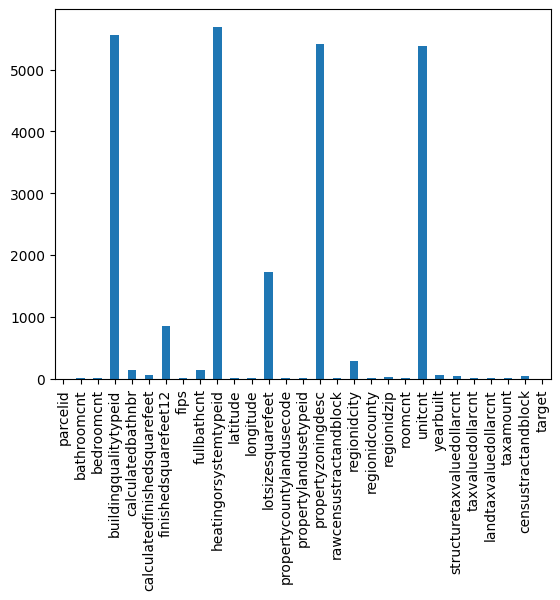

In [11]:
df.isnull().sum().plot.bar()
plt.show()

In [13]:
for col in df.columns:
  if df[col].dtype=='object':
    df[col]=df[col].fillna(df[col].mode()[0])
  elif df[col].dtype==np.number:
    df[col]=df[col].fillna(df[col].mean())



df.isnull().sum().sum()


np.int64(0)

In [14]:
#Exploratory Data Analysis(EDA)
#analyzing the data using visual tecnique
#used to check treands,patterns
ints,objects,floats=[],[],[]

for col in df.columns:
  if df[col].dtype==float:
    floats.append(col)
  elif df[col].dtype==int:
    ints.append(col)
  else:
    objects.append(col)


len(ints),len(floats),len(objects)


(1, 26, 2)

In [15]:
for col in objects:
  print(col,'->',df[col].nunique())
  print(df[col].unique())
  print()

propertycountylandusecode -> 52
['122' '1110' '0101' '010C' '1129' '0100' '38' '34' '1111' '012C' '010V'
 '1' '0103' '010D' '0200' '010E' '0300' '96' '0104' '0400' '01DC' '01HC'
 '1321' '1410' '0108' '1128' '010G' '1720' '010H' '1210' '0102' '010F'
 '010M' '1117' '0201' '0700' '1722' '73' '0109' '0301' '01HE' '135' '0204'
 '0401' '070D' '0113' '0133' '0131' '1432' '040G' '1112' '1222']

propertyzoningdesc -> 1132
['LAR1' 'LCR110000*' 'LAR3' ... 'ARR3HV' 'LCA1600*' 'LR 6000']



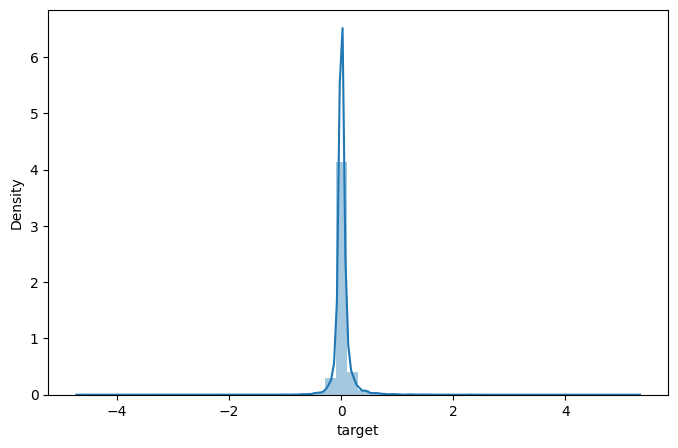

In [17]:
plt.figure(figsize=(8,5))
sns.distplot(df['target'])
plt.show()

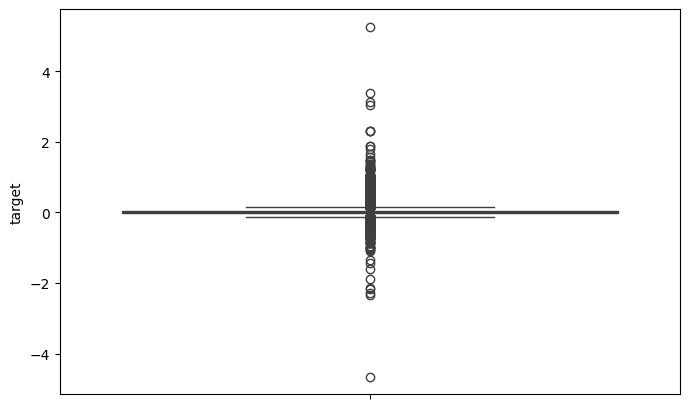

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(df['target'])
plt.show()

In [19]:
print('Shape of the dataframe beofre removal of outliners',df.shape)
df=df[(df['target']>-1) & (df['target']< 1)]
print('shape of the dataframe after removal of outliers',df.shape)


Shape of the dataframe beofre removal of outliners (15900, 29)
shape of the dataframe after removal of outliers (15844, 29)


In [21]:
for col in objects:
  le=LabelEncoder()
  df[col]=le.fit_transform(df[col])


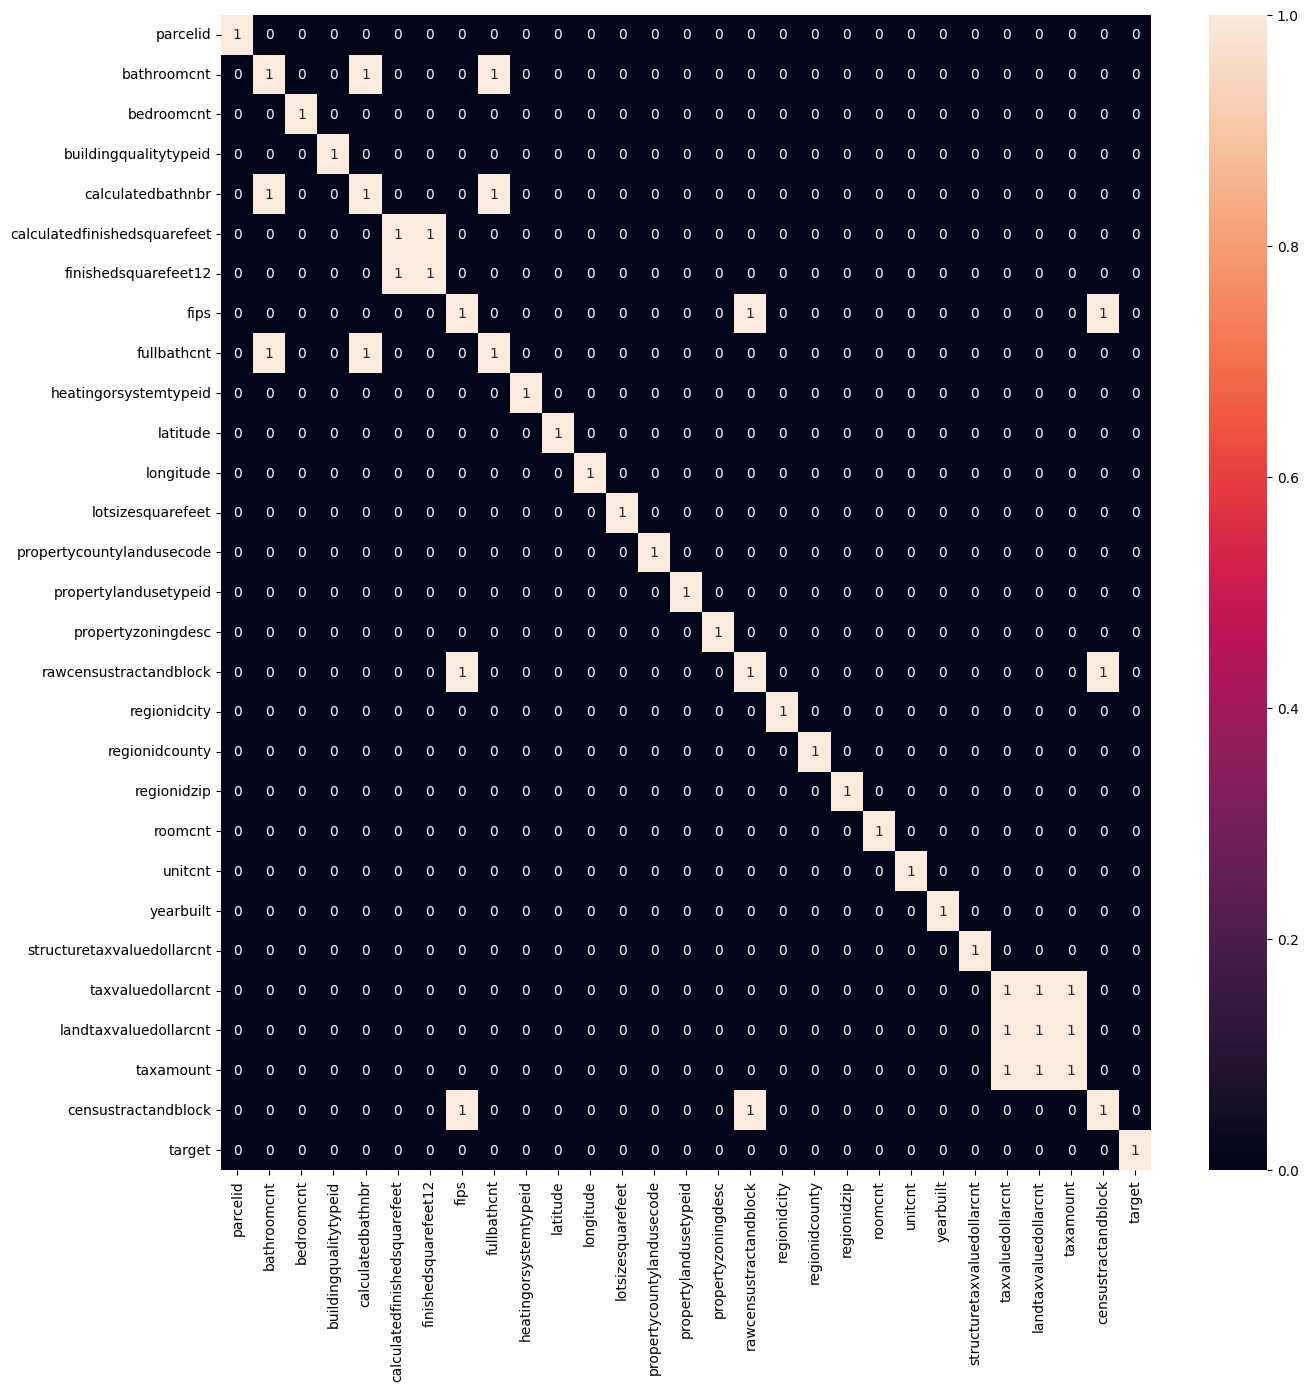

In [22]:
plt.figure(figsize=(15,15))
sns.heatmap(df.corr() > 0.8,annot=True,cbar=True)
plt.show()

In [23]:
to_remove=['calculatedbathnbr', 'fullbathcnt', 'fips',
             'rawcensustractandblock', 'taxvaluedollarcnt',
             'finishedsquarefeet12', 'landtaxvaluedollarcnt']


df.drop(to_remove,axis=1,inplace=True)



In [25]:
features=df.drop(['parcelid'],axis=1)
target=df['target'].values

X_train,X_test,y_train,y_test=train_test_split(features,target,test_size=0.1,random_state=42)

X_train.shape,X_test.shape

((14259, 21), (1585, 21))

In [27]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error as mae
models=[LinearRegression(),XGBRegressor(),Lasso(),RandomForestRegressor(),Ridge()]


for i in range(5):
  models[i].fit(X_train,y_train)
  print(f'{models[i]}:')

  train_pred=models[i].predict(X_train)
  print('Training Error: ',mae(y_train,train_pred))

  val_preds=models[i].predict(X_test)
  print('Validation Error:',mae(y_test, val_preds))
  print()

LinearRegression():
Training Error:  4.943489162470443e-17
Validation Error: 0.05841841818525031

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...):
Training Error:  0.000682582502746765
Validation Error: 0.058308502750013584

Lasso():
Training Error:  0.06716778409020835
Validation Error: 0.0665483